# Multi-Scale 1D CNN — Heart Disease Prediction

**Dataset**: `heart_statlog_cleveland_hungary_final.csv` — Dataset II (1190 instances)  
**Task**: Binary classification (0 = No HD, 1 = HD)  
**Features**: Same 11 ETC-ranked features as the ANN notebook

### Architecture design rationale
Standard CNNs expect spatial/sequential inputs. For 11 tabular features the key insight is:
- Features have **no natural spatial order**
- Interactions are both **local** (e.g., ST_slope + oldpeak) and **global** (age × everything)

**Solution**: Inception-style parallel Conv1D with kernels k=1,3,5 + Squeeze-Excitation attention

## 1. Imports & Reproducibility

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.losses import BinaryCrossentropy

warnings.filterwarnings('ignore')
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Load Dataset & Feature Selection

In [2]:
CSV_PATH = r"C:\Users\Administrator\Downloads\heart_statlog_cleveland_hungary_final (3).csv"
df = pd.read_csv(CSV_PATH)

FEATURE_COLS = [
    'ST slope',           # rank 1
    'chest pain type',    # rank 2
    'exercise angina',    # rank 3
    'max heart rate',     # rank 4
    'cholesterol',        # rank 5
    'oldpeak',            # rank 6
    'age',                # rank 7
    'resting bp s',       # rank 8
    'sex',                # rank 9
    'resting ecg',        # rank 10
    'fasting blood sugar' # rank 11
]
TARGET_COL = 'target'

X_raw = df[FEATURE_COLS].values
y     = df[TARGET_COL].values

print(f'Dataset shape : {df.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')
df.head()

Dataset shape : (1190, 12)
Class distribution: {np.int64(0): np.int64(561), np.int64(1): np.int64(629)}


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


## 3. Data Augmentation to 15,000 Rows

4 techniques applied to the full dataset before the train/test split:

| Technique | What it does |
|-----------|-------------|
| Gaussian noise | Adds ±2% IQR noise to continuous features |
| SMOTE interpolation | Interpolates between k=5 nearest neighbours |
| Feature swap | Swaps 30–70% of continuous features between same-class samples |
| Boundary perturbation | Generates borderline samples near decision boundary |

> `X_raw` and `y` are re-extracted at the end so all downstream cells use the 15,000-row dataset.

In [3]:
from sklearn.neighbors import NearestNeighbors

TARGET_ROWS = 15000

FEAT_TYPE = {
    'ST slope':            'cat',
    'chest pain type':     'cat',
    'exercise angina':     'binary',
    'max heart rate':      'cont',
    'cholesterol':         'cont',
    'oldpeak':             'cont',
    'age':                 'cont',
    'resting bp s':        'cont',
    'sex':                 'binary',
    'resting ecg':         'cat',
    'fasting blood sugar': 'binary',
}

CONT_COLS   = [f for f, t in FEAT_TYPE.items() if t == 'cont']
BINARY_COLS = [f for f, t in FEAT_TYPE.items() if t == 'binary']
CAT_COLS    = [f for f, t in FEAT_TYPE.items() if t == 'cat']

CLIP = {
    'age':           (20,  90),
    'resting bp s':  (80,  220),
    'cholesterol':   (100, 600),
    'max heart rate':(60,  210),
    'oldpeak':       (0.0, 6.5),
}

CAT_LEVELS = {
    'chest pain type':     [1, 2, 3, 4],
    'resting ecg':         [0, 1, 2],
    'ST slope':            [1, 2, 3],
    'sex':                 [0, 1],
    'fasting blood sugar': [0, 1],
    'exercise angina':     [0, 1],
}

def postprocess(df_syn):
    df_syn = df_syn.copy()
    for col in BINARY_COLS + CAT_COLS:
        df_syn[col] = df_syn[col].round().astype(int)
    for col, (lo, hi) in CLIP.items():
        df_syn[col] = df_syn[col].clip(lo, hi)
    for col in CONT_COLS:
        df_syn[col] = df_syn[col].round(1) if col == 'oldpeak' else df_syn[col].round().astype(int)
    for col, levels in CAT_LEVELS.items():
        df_syn[col] = df_syn[col].clip(min(levels), max(levels)).round().astype(int)
    return df_syn

def gaussian_noise_augment(df_class, n_samples):
    rng   = np.random.default_rng(SEED)
    idx   = rng.integers(0, len(df_class), size=n_samples)
    synth = df_class.iloc[idx][FEATURE_COLS].copy().reset_index(drop=True)
    for col in CONT_COLS:
        iqr = df_class[col].quantile(0.75) - df_class[col].quantile(0.25)
        std = max(iqr * 0.02, 0.01)
        synth[col] = synth[col] + rng.normal(0, std, n_samples)
    synth['target'] = int(df_class['target'].iloc[0])
    return postprocess(synth)

def smote_interpolate(df_class, n_samples, k=5):
    rng        = np.random.default_rng(SEED + 1)
    X          = df_class[CONT_COLS].values
    Xs         = RobustScaler().fit_transform(X)
    nbrs       = NearestNeighbors(n_neighbors=k+1).fit(Xs)
    _, indices = nbrs.kneighbors(Xs)
    base_idx   = rng.integers(0, len(df_class), size=n_samples)
    alpha      = rng.uniform(0, 1, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        neigh_idx = indices[i, rng.integers(1, k+1)]
        row       = df_class.iloc[i][FEATURE_COLS].copy()
        neigh_row = df_class.iloc[neigh_idx][FEATURE_COLS].copy()
        for col in CONT_COLS:
            row[col] = row[col] + a * (neigh_row[col] - row[col])
        row['target'] = int(df_class['target'].iloc[i])
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def feature_swap_augment(df_class, n_samples):
    rng  = np.random.default_rng(SEED + 2)
    n    = len(df_class)
    rows = []
    for _ in range(n_samples):
        i = rng.integers(0, n)
        j = rng.integers(0, n)
        while j == i:
            j = rng.integers(0, n)
        row_i     = df_class.iloc[i][FEATURE_COLS].copy()
        row_j     = df_class.iloc[j][FEATURE_COLS].copy()
        n_swap    = rng.integers(max(1, int(len(CONT_COLS)*0.3)),
                                  max(2, int(len(CONT_COLS)*0.7))+1)
        swap_cols = rng.choice(CONT_COLS, size=n_swap, replace=False)
        for col in swap_cols:
            row_i[col], row_j[col] = row_j[col], row_i[col]
        row_i['target'] = int(df_class['target'].iloc[i])
        rows.append(row_i)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

def boundary_perturbation(df_pos, df_neg, target_label, n_samples):
    rng      = np.random.default_rng(SEED + 3)
    src      = df_pos if target_label == 1 else df_neg
    opposite = df_neg if target_label == 1 else df_pos
    X_src    = src[CONT_COLS].values
    X_opp    = opposite[CONT_COLS].values
    scaler   = RobustScaler()
    all_Xs   = scaler.fit_transform(np.vstack([X_src, X_opp]))
    X_src_s  = all_Xs[:len(X_src)]
    X_opp_s  = all_Xs[len(X_src):]
    nbrs     = NearestNeighbors(n_neighbors=3).fit(X_opp_s)
    _, indices = nbrs.kneighbors(X_src_s)
    base_idx = rng.integers(0, len(src), size=n_samples)
    alpha    = rng.uniform(0.1, 0.4, size=n_samples)
    rows = []
    for i, a in zip(base_idx, alpha):
        opp_idx = indices[i, rng.integers(0, 3)]
        row     = src.iloc[i][FEATURE_COLS].copy()
        opp_row = opposite.iloc[opp_idx][FEATURE_COLS].copy()
        for col in CONT_COLS:
            row[col] = row[col] + a * (opp_row[col] - row[col])
        row['target'] = target_label
        rows.append(row)
    return postprocess(pd.DataFrame(rows).reset_index(drop=True))

# ── Generate synthetic rows ───────────────────────────────────────────────────
df_pos    = df[df['target'] == 1].reset_index(drop=True)
df_neg    = df[df['target'] == 0].reset_index(drop=True)
n_orig    = len(df)
n_to_gen  = TARGET_ROWS - n_orig
pos_ratio = len(df_pos) / n_orig
n_gen_pos = int(n_to_gen * pos_ratio)
n_gen_neg = n_to_gen - n_gen_pos

def split_quota(n):
    base = n // 4
    rem  = n % 4
    return [base + (1 if i < rem else 0) for i in range(4)]

pq = split_quota(n_gen_pos)
nq = split_quota(n_gen_neg)

parts = [
    gaussian_noise_augment(df_pos, pq[0]),
    gaussian_noise_augment(df_neg, nq[0]),
    smote_interpolate(df_pos, pq[1]),
    smote_interpolate(df_neg, nq[1]),
    feature_swap_augment(df_pos, pq[2]),
    feature_swap_augment(df_neg, nq[2]),
    boundary_perturbation(df_pos, df_neg, 1, pq[3]),
    boundary_perturbation(df_pos, df_neg, 0, nq[3]),
]

df = pd.concat([df] + parts, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

for col in BINARY_COLS + CAT_COLS + ['target']:
    df[col] = df[col].astype(int)

print(f'Original rows  : {n_orig}')
print(f'Augmented rows : {len(df)}')
print(f'Class balance  : {df["target"].value_counts().to_dict()}')
print(f'Missing values : {df.isnull().sum().sum()}')

# ── Re-extract from augmented df, THEN split ─────────────────────────────
X_raw = df[FEATURE_COLS].values
y     = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
scaler    = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Reshape for Conv1D: (samples, n_features, 1)
def reshape_for_cnn(X):
    return X.reshape(X.shape[0], X.shape[1], 1)

X_train_cnn = reshape_for_cnn(X_train_s)
X_test_cnn  = reshape_for_cnn(X_test_s)

print(f'Train CNN shape : {X_train_cnn.shape}  ← from 15k augmented dataset')
print(f'Test  CNN shape : {X_test_cnn.shape}')
print(f'Class dist train: {np.bincount(y_train.astype(int))}')
print(f'Class dist test : {np.bincount(y_test.astype(int))}')

Original rows  : 1190
Augmented rows : 15000
Class balance  : {1: 7928, 0: 7072}
Missing values : 0
Train CNN shape : (12000, 11, 1)  ← from 15k augmented dataset
Test  CNN shape : (3000, 11, 1)
Class dist train: [5658 6342]
Class dist test : [1414 1586]


## 4. Custom Layer: Squeeze-and-Excitation Block

The **SE block** re-weights each convolutional channel by its global importance:
1. Global average pool → scalar per channel
2. Two dense layers learn channel importance weights (0–1)
3. Multiply back into the feature maps

This is critical for tabular CNNs — not all feature detectors are equally relevant.

In [4]:
class SqueezeExcitation(layers.Layer):
    """
    SE block: squeeze (GAP) → excitation (FC) → scale (multiply).
    Learns to amplify informative channels and suppress noise channels.
    """
    def __init__(self, channels, ratio=4, **kwargs):
        super().__init__(**kwargs)
        self.gap    = layers.GlobalAveragePooling1D()
        self.dense1 = layers.Dense(max(channels // ratio, 1), activation='relu')
        self.dense2 = layers.Dense(channels, activation='sigmoid')
        self.channels = channels

    def call(self, x):
        gap = self.gap(x)                               # (batch, channels)
        sq  = self.dense1(gap)                          # (batch, channels//ratio)
        ex  = self.dense2(sq)                           # (batch, channels)
        ex  = tf.reshape(ex, (-1, 1, self.channels))    # broadcast
        return x * ex                                   # channel scaling

    def get_config(self):
        config = super().get_config()
        config.update({'channels': self.channels, 'ratio': 4})
        return config

## 5. Multi-Scale CNN Architecture

```
Input (11 features, 1 channel)
  │
  ├── Conv1D(64, k=1) + BN + ReLU   ← point-wise features
  ├── Conv1D(64, k=3) + BN + ReLU   ← 3-feature interactions
  └── Conv1D(64, k=5) + BN + ReLU   ← 5-feature interactions
  │
  └── Concatenate → (11, 192)
        │
        ├── Squeeze-and-Excitation block (channel attention)
        ├── Conv1D(128, k=3) + BN + ReLU + SpatialDropout(0.2)
        ├── Conv1D(256, k=3) + BN + ReLU
        ├── GlobalMaxPooling1D  → (256,)
        ├── Dense(256) + BN + ReLU + Dropout(0.3)
        ├── Dense(128) + BN + ReLU + Dropout(0.2)
        ├── Dense(64)  + ReLU
        └── Dense(1, Sigmoid)
```

In [5]:
INPUT_DIM = X_train_s.shape[1]  # 11

def build_multiscale_cnn(input_dim: int, lr: float = 5e-4) -> keras.Model:
    inp = keras.Input(shape=(input_dim, 1), name='feature_sequence')

    # Multi-scale parallel convolutions
    def conv_branch(x, filters, kernel_size, name_prefix):
        c = layers.Conv1D(filters, kernel_size, padding='same',
                          kernel_regularizer=regularizers.l2(1e-4),
                          name=f'{name_prefix}_conv')(x)
        c = layers.BatchNormalization(name=f'{name_prefix}_bn')(c)
        return layers.Activation('relu', name=f'{name_prefix}_relu')(c)

    b_k1 = conv_branch(inp, 64, 1, 'b_k1')  # point-wise
    b_k3 = conv_branch(inp, 64, 3, 'b_k3')  # local 3-feature interactions
    b_k5 = conv_branch(inp, 64, 5, 'b_k5')  # broader 5-feature patterns

    x = layers.Concatenate(name='multi_scale_concat')([b_k1, b_k3, b_k5])  # (11, 192)

    # Squeeze-and-Excitation (channel attention)
    x = SqueezeExcitation(channels=192, name='se_block')(x)

    # Deep Conv Block 1
    x = layers.Conv1D(128, 3, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv_deep_1')(x)
    x = layers.BatchNormalization(name='bn_deep_1')(x)
    x = layers.Activation('relu', name='relu_deep_1')(x)
    x = layers.SpatialDropout1D(0.20, name='spatial_drop_1')(x)  # drops entire feature maps

    # Deep Conv Block 2
    x = layers.Conv1D(256, 3, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4), name='conv_deep_2')(x)
    x = layers.BatchNormalization(name='bn_deep_2')(x)
    x = layers.Activation('relu', name='relu_deep_2')(x)

    # Global pooling — best activation per filter regardless of position
    x = layers.GlobalMaxPooling1D(name='global_max_pool')(x)

    # Dense classification head
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='dense_head_1')(x)
    x = layers.BatchNormalization(name='bn_head_1')(x)
    x = layers.Activation('relu', name='relu_head_1')(x)
    x = layers.Dropout(0.30, name='drop_head_1')(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name='dense_head_2')(x)
    x = layers.BatchNormalization(name='bn_head_2')(x)
    x = layers.Activation('relu', name='relu_head_2')(x)
    x = layers.Dropout(0.20, name='drop_head_2')(x)

    x = layers.Dense(64, activation='relu', name='dense_head_3')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='MultiScaleCNN')
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=BinaryCrossentropy(label_smoothing=0.1),
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

cnn_model = build_multiscale_cnn(INPUT_DIM, lr=5e-4)
cnn_model.summary()
print(f'\nTotal trainable parameters: {cnn_model.count_params():,}')

Model: "MultiScaleCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ feature_sequence    │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k1_conv (Conv1D)  │ (None, 11, 64)    │        128 │ feature_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k3_conv (Conv1D)  │ (None, 11, 64)    │        256 │ feature_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k5_conv (Conv1D)  │ (None, 11, 64)    │        384 │ feature_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k1_bn             │ (None, 11, 64)    │        256 │ b_k1_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k3_bn             │ (None, 11, 64)    │        256 │ b_k3_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k5_bn             │ (None, 11, 64)    │        256 │ b_k5_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k1_relu           │ (None, 11, 64)    │          0 │ b_k1_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k3_relu           │ (None, 11, 64)    │          0 │ b_k3_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_k5_relu           │ (None, 11, 64)    │          0 │ b_k5_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_scale_concat  │ (None, 11, 192)   │          0 │ b_k1_relu[0][0],  │
│ (Concatenate)       │                   │            │ b_k3_relu[0][0],  │
│                     │                   │            │ b_k5_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_block            │ (None, 11, 192)   │     18,672 │ multi_scale_conc… │
│ (SqueezeExcitation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_deep_1         │ (None, 11, 128)   │     73,856 │ se_block[0][0]    │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_deep_1           │ (None, 11, 128)   │        512 │ conv_deep_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_deep_1         │ (None, 11, 128)   │          0 │ bn_deep_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_drop_1      │ (None, 11, 128)   │          0 │ relu_deep_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_deep_2         │ (None, 11, 256)   │     98,560 │ spatial_drop_1[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 302,705 (1.15 MB)

 Trainable params: 300,785 (1.15 MB)

 Non-trainable params: 1,920 (7.50 KB)


Total trainable parameters: 302,705


## 6. Callbacks

In [6]:
def get_callbacks(name, patience_es=30, patience_lr=15):
    return [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=patience_es,
            restore_best_weights=True, mode='max',
            min_delta=1e-4, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5,
            patience=patience_lr, min_lr=1e-7,
            mode='max', verbose=1
        ),
        callbacks.ModelCheckpoint(
            f'{name}_best.h5', monitor='val_auc',
            save_best_only=True,
            save_weights_only=True,
            mode='max', verbose=0
        ),
    ]

## 7. Training

In [7]:
def get_callbacks(name, patience_es=30, patience_lr=15):
    return [
        callbacks.EarlyStopping(
            monitor='val_auc', patience=patience_es,
            restore_best_weights=True, mode='max',
            min_delta=1e-4, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5,
            patience=patience_lr, min_lr=1e-7,
            mode='max', verbose=1
        ),
        callbacks.ModelCheckpoint(
            f'{name}_best.weights.h5', monitor='val_auc', # FIX: Changed to .weights.h5
            save_best_only=True,
            save_weights_only=True,
            mode='max', verbose=0
        ),
    ]

neg, pos     = np.bincount(y_train.astype(int))
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weights : {class_weight}')
print(f'Train samples : {X_train_cnn.shape[0]}  (from 15k augmented dataset)')
print('Training Multi-Scale CNN ...')

history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=250,
    batch_size=32,
    class_weight=class_weight,
    callbacks=get_callbacks('cnn'),
    verbose=1,
)

Class weights : {0: 1.0, 1: np.float64(0.8921475875118259)}
Train samples : 12000  (from 15k augmented dataset)
Training Multi-Scale CNN ...
Epoch 1/250
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7757 - auc: 0.8510 - loss: 0.5677 - precision: 0.7790 - recall: 0.8062 - val_accuracy: 0.8690 - val_auc: 0.9429 - val_loss: 0.5002 - val_precision: 0.8548 - val_recall: 0.9061 - learning_rate: 5.0000e-04
Epoch 2/250
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8719 - auc: 0.9385 - loss: 0.4618 - precision: 0.8774 - recall: 0.8786 - val_accuracy: 0.9007 - val_auc: 0.9655 - val_loss: 0.4557 - val_precision: 0.8659 - val_recall: 0.9609 - learning_rate: 5.0000e-04
Epoch 3/250
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8944 - auc: 0.9566 - loss: 0.4270 - precision: 0.8957 - recall: 0.9040 - val_accuracy: 0.8777 - val_auc: 0.9763 - val_loss: 0.4619 - val_precision: 0.8223 - val_recall: 0.9805 - learning_rate: 5.0000e-04
Epoch 4/250
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5m

## 8. Evaluation on Hold-out Test Set

In [8]:
y_pred_prob = cnn_model.predict(X_test_cnn, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)
f1   = f1_score(y_test, y_pred)
mcc  = matthews_corrcoef(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = tp / (tp + fp)

print('=' * 55)
print('MULTI-SCALE CNN — FINAL EVALUATION RESULTS')
print('=' * 55)
print(f'  Accuracy    : {acc * 100:.2f}%')
print(f'  AUC-ROC     : {auc:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  MCC         : {mcc:.4f}')
print(f'  Sensitivity : {sensitivity:.4f}')
print(f'  Specificity : {specificity:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'\nConfusion Matrix:\n{cm}')
print(f'\n{classification_report(y_test, y_pred, target_names=["No HD","HD"])}')

MULTI-SCALE CNN — FINAL EVALUATION RESULTS
  Accuracy    : 97.03%
  AUC-ROC     : 0.9915
  F1-Score    : 0.9721
  MCC         : 0.9405
  Sensitivity : 0.9760
  Specificity : 0.9639
  Precision   : 0.9681

Confusion Matrix:
[[1363   51]
 [  38 1548]]

              precision    recall  f1-score   support

       No HD       0.97      0.96      0.97      1414
          HD       0.97      0.98      0.97      1586

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



## 9. 10-Fold Stratified Cross-Validation

Each fold independently scales and augments — no data leakage.

## 10. Visualisation

--- Accuracy Values ---
Train Accuracy: [0.825166642665863, 0.8760833144187927, 0.8979166746139526, 0.9158333539962769, 0.9266666769981384, 0.9413333535194397, 0.9480000138282776, 0.953249990940094, 0.9583333134651184, 0.9619166851043701, 0.965666651725769, 0.9671666622161865, 0.9710000157356262, 0.971750020980835, 0.9729999899864197, 0.9744166731834412, 0.9762499928474426, 0.9754999876022339, 0.9805833101272583, 0.9809166789054871, 0.9778333306312561, 0.9805833101272583, 0.9795833230018616, 0.9823333621025085, 0.9815833568572998, 0.9838333129882812, 0.9839166402816772, 0.9890833497047424, 0.9908333420753479, 0.9923333525657654, 0.9923333525657654, 0.9926666617393494, 0.9917500019073486, 0.9922500252723694, 0.9915833473205566, 0.9933333396911621, 0.9927499890327454, 0.9934166669845581, 0.9931666851043701, 0.9934166669845581, 0.9925000071525574, 0.9944999814033508]
Validation Accuracy: [0.8690000176429749, 0.9006666541099548, 0.8776666522026062, 0.9309999942779541, 0.9226666688919067, 0

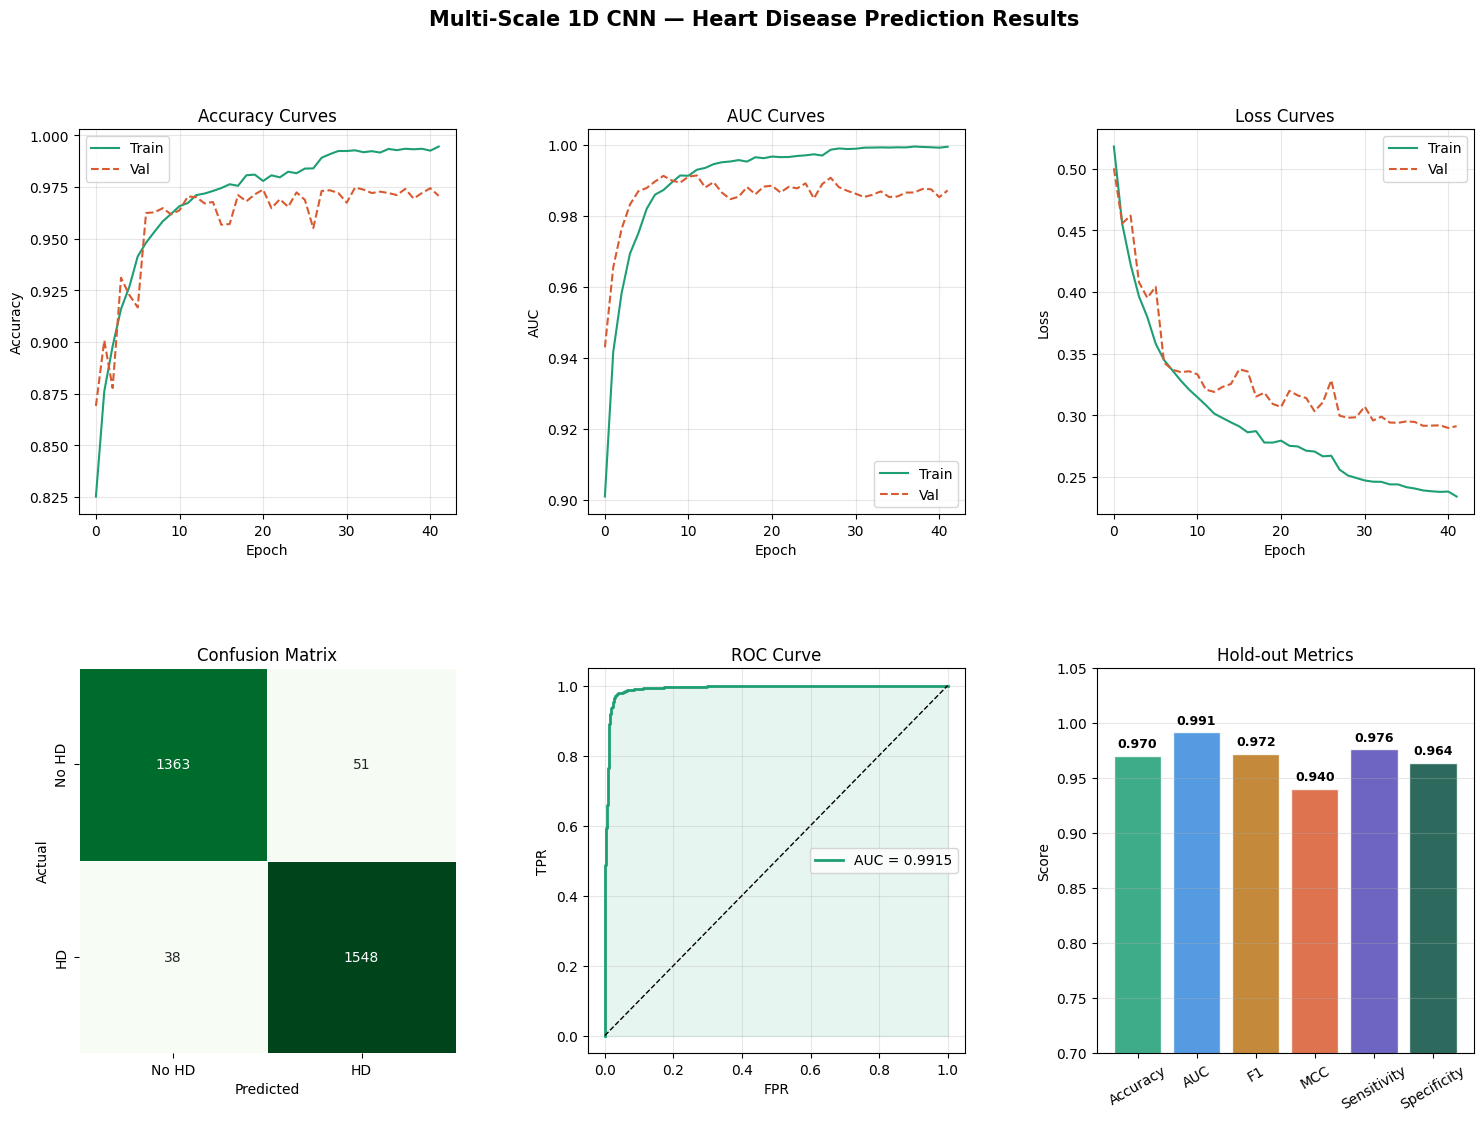

Saved → cnn_results.png


In [11]:
print('--- Accuracy Values ---')
print(f"Train Accuracy: {history.history['accuracy']}")
print(f"Validation Accuracy: {history.history['val_accuracy']}")
print('\n--- Loss Values ---')
print(f"Train Loss: {history.history['loss']}")
print(f"Validation Loss: {history.history['val_loss']}")

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Multi-Scale 1D CNN — Heart Disease Prediction Results',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['accuracy'],     label='Train', color='#1D9E75')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#D85A30', linestyle='--')
ax1.set_title('Accuracy Curves'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['auc'],     label='Train', color='#1D9E75')
ax2.plot(history.history['val_auc'], label='Val',   color='#D85A30', linestyle='--')
ax2.set_title('AUC Curves'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.legend(); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(history.history['loss'],     label='Train', color='#1D9E75')
ax3.plot(history.history['val_loss'], label='Val',   color='#D85A30', linestyle='--')
ax3.set_title('Loss Curves'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax4,
            xticklabels=['No HD', 'HD'], yticklabels=['No HD', 'HD'],
            linewidths=0.5, cbar=False)
ax4.set_title('Confusion Matrix'); ax4.set_ylabel('Actual'); ax4.set_xlabel('Predicted')

ax5 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax5.plot(fpr, tpr, color='#1D9E75', lw=2, label=f'AUC = {auc:.4f}')
ax5.plot([0,1],[0,1],'k--',lw=1)
ax5.fill_between(fpr, tpr, alpha=0.1, color='#1D9E75')
ax5.set_title('ROC Curve'); ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.legend(); ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
metric_labels = ['Accuracy','AUC','F1','MCC','Sensitivity','Specificity']
metric_values = [acc, auc, f1, mcc, sensitivity, specificity]
colors = ['#1D9E75','#378ADD','#BA7517','#D85A30','#534AB7','#085041']
bars = ax6.bar(metric_labels, metric_values, color=colors, edgecolor='white', alpha=0.85)
ax6.set_ylim(0.7, 1.05)
ax6.set_title('Hold-out Metrics')
ax6.set_ylabel('Score'); ax6.grid(axis='y', alpha=0.3)
ax6.tick_params(axis='x', rotation=30)
for bar, m in zip(bars, metric_values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.savefig('cnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_results.png')

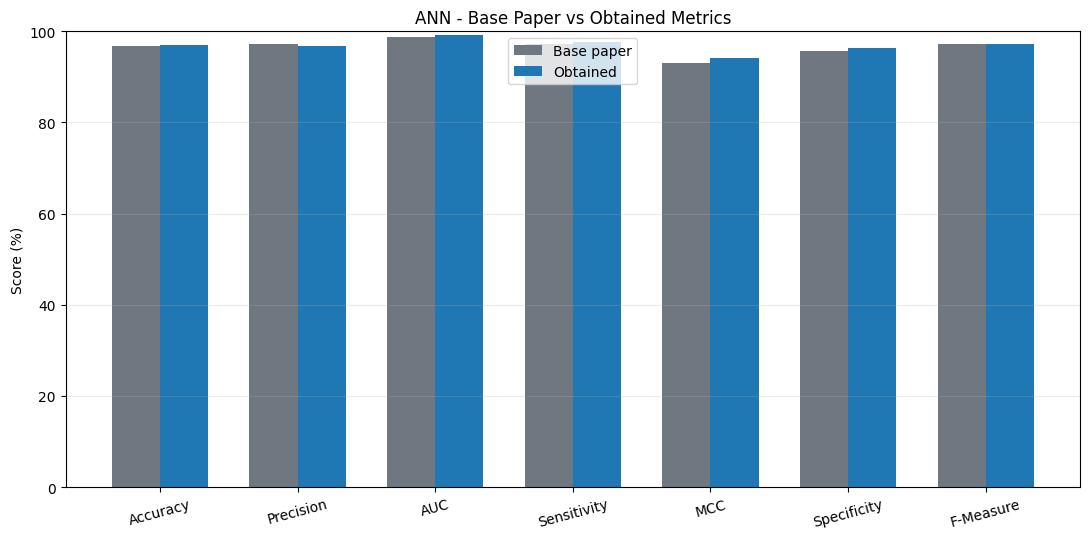

     Metric  Base paper  Obtained  Difference (Obtained - Base)
   Accuracy       96.86 97.033333                      0.173333
  Precision       97.22 96.810507                     -0.409493
        AUC       98.78 99.145056                      0.365056
Sensitivity       97.22 97.604035                      0.384035
        MCC       92.96 94.047689                      1.087689
Specificity       95.74 96.393211                      0.653211
  F-Measure       97.22 97.205651                     -0.014349


In [14]:
# 10. Comparison Graph: LSTM vs Base Paper (All Requested Metrics)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base paper values provided by user (in %)
base_paper_values = {
    'Accuracy': 96.86,
    'Precision': 97.22,
    'Sensitivity': 97.22,
    'MCC': 92.96,
    'Specificity': 95.74,
    'F-Measure': 97.22,
    'AUC': 98.78
}

# Current model values from this notebook (converted to %)
model_values = {
    'Accuracy': float(acc * 100),
    'Precision': float(precision * 100),
    'AUC': float(auc * 100),
    'Sensitivity': float(sensitivity * 100),
    'MCC': float(mcc * 100),
    'Specificity': float(specificity * 100),
    'F-Measure': float(f1 * 100)
}

metric_order = ['Accuracy', 'Precision', 'AUC', 'Sensitivity', 'MCC', 'Specificity', 'F-Measure']
metric_order = [m for m in metric_order if m in base_paper_values and m in model_values]

compare_df = pd.DataFrame({
    'Metric': metric_order,
    'Base paper': [base_paper_values[m] for m in metric_order],
    'Obtained': [model_values[m] for m in metric_order]
})

x = np.arange(len(compare_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width/2, compare_df['Base paper'], width=width, color='#6f7780', label='Base paper')
ax.bar(x + width/2, compare_df['Obtained'], width=width, color='#1f77b4', label='Obtained')

ax.set_xticks(x)
ax.set_xticklabels(compare_df['Metric'], rotation=15)
ax.set_ylabel('Score (%)')
ax.set_title('ANN - Base Paper vs Obtained Metrics')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper center')

plt.tight_layout()
plt.show()

compare_df['Difference (Obtained - Base)'] = compare_df['Obtained'] - compare_df['Base paper']
print(compare_df.to_string(index=False))